In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:


from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB 
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("dataset_phishing.csv/dataset_phishing.csv")

In [7]:
df.head(10)

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
5,http://appleid.apple.com-app.es/,32,24,0,3,1,0,0,0,0,...,1,1,1,0,-1,0,0,1,0,phishing
6,http://www.mutuo.it,19,12,0,2,0,0,0,0,0,...,0,1,0,170,7529,0,0,0,1,legitimate
7,http://www.shadetreetechnology.com/V4/validati...,81,27,1,2,0,0,0,0,0,...,1,0,0,76,5767,0,0,1,2,phishing
8,http://vamoaestudiarmedicina.blogspot.com/,42,34,0,2,0,0,0,0,0,...,1,1,0,371,7298,0,0,0,5,legitimate
9,https://parade.com/425836/joshwigler/the-amazi...,104,10,0,1,10,0,0,0,0,...,1,0,0,128,9368,6774,0,0,5,legitimate


In [8]:
df.shape

(11430, 89)

In [9]:

df.dtypes

url                  str
length_url         int64
length_hostname    int64
ip                 int64
nb_dots            int64
                   ...  
web_traffic        int64
dns_record         int64
google_index       int64
page_rank          int64
status               str
Length: 89, dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

In [11]:
df.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


In [12]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

In [19]:
df = df.drop_duplicates()

In [20]:
df = df.drop(columns=["url"])

In [21]:

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])


In [22]:
df.head(4)

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,37,19,0,3,0,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,77,23,1,1,0,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,126,50,1,4,1,0,1,2,0,3,...,1,0,0,14,4004,5828815,0,1,0,1
3,18,11,0,2,0,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,0


In [23]:
print(df.dtypes)

length_url         int64
length_hostname    int64
ip                 int64
nb_dots            int64
nb_hyphens         int64
                   ...  
web_traffic        int64
dns_record         int64
google_index       int64
page_rank          int64
status             int64
Length: 88, dtype: object


In [24]:

drop_cols = [
    'url','ip','nb_at','nb_qm','nb_and','nb_or','nb_eq','nb_underscore',
    'nb_tilde','nb_percent','nb_star','nb_colon','nb_comma','nb_semicolumn',
    'nb_dollar','nb_space','nb_com','nb_dslash','http_in_path','ratio_digits_host',
    'punycode','port','tld_in_path','tld_in_subdomain','abnormal_subdomain',
    'prefix_suffix','random_domain','shortening_service','path_extension',
    'nb_external_redirection','phish_hints','domain_in_brand','brand_in_subdomain',
    'brand_in_path','suspecious_tld','statistical_report','ratio_nullHyperlinks',
    'ratio_intRedirection','ratio_intErrors','login_form','submit_email','sfh',
    'iframe','popup_window','onmouseover','right_clic','empty_title',
    'domain_in_title','whois_registered_domain','dns_record','nb_redirection','ratio_extErrors','shortest_words_raw','nb_extCSS','nb_hyphens',
    'ratio_extMedia','external_favicon','ratio_extRedirection','domain_registration_length','domain_with_copyright','safe_anchor','links_in_tags',
    'ratio_intHyperlinks','domain_age','nb_hyperlinks','nb_www','page_rank','ratio_intMedia'

]



In [26]:
df.head(4)

,length_url,length_hostname,nb_dots,nb_slash,https_token,ratio_digits_url,nb_subdomains,length_words_raw,char_repeat,shortest_word_host,...,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,ratio_extHyperlinks,web_traffic,google_index,status
0,37,19,3,3,1,0.000000,3,4,4,3,...,11,11,6,5.75,7.0,4.500000,0.470588,0,1,0
1,77,23,1,5,1,0.220779,1,4,4,19,...,32,19,32,15.75,19.0,14.666667,0.033333,0,1,1
2,126,50,4,5,0,0.150794,3,12,2,3,...,17,13,17,8.25,8.4,8.142857,0.000000,5828815,1,1
3,18,11,2,2,1,0.000000,2,1,0,5,...,5,5,0,5.00,5.0,0.000000,0.026846,107721,0,0


In [27]:
 pip install feature_engine

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Separate features and target
X = df.drop('status',axis=1)   # all columns except target
y = df['status']                  # target column


In [29]:
df.shape

(11430, 21)

In [30]:
df.dtypes

length_url               int64
length_hostname          int64
nb_dots                  int64
nb_slash                 int64
https_token              int64
ratio_digits_url       float64
nb_subdomains            int64
length_words_raw         int64
char_repeat              int64
shortest_word_host       int64
shortest_word_path       int64
longest_words_raw        int64
longest_word_host        int64
longest_word_path        int64
avg_words_raw          float64
avg_word_host          float64
avg_word_path          float64
ratio_extHyperlinks    float64
web_traffic              int64
google_index             int64
status                   int64
dtype: object

EDA 

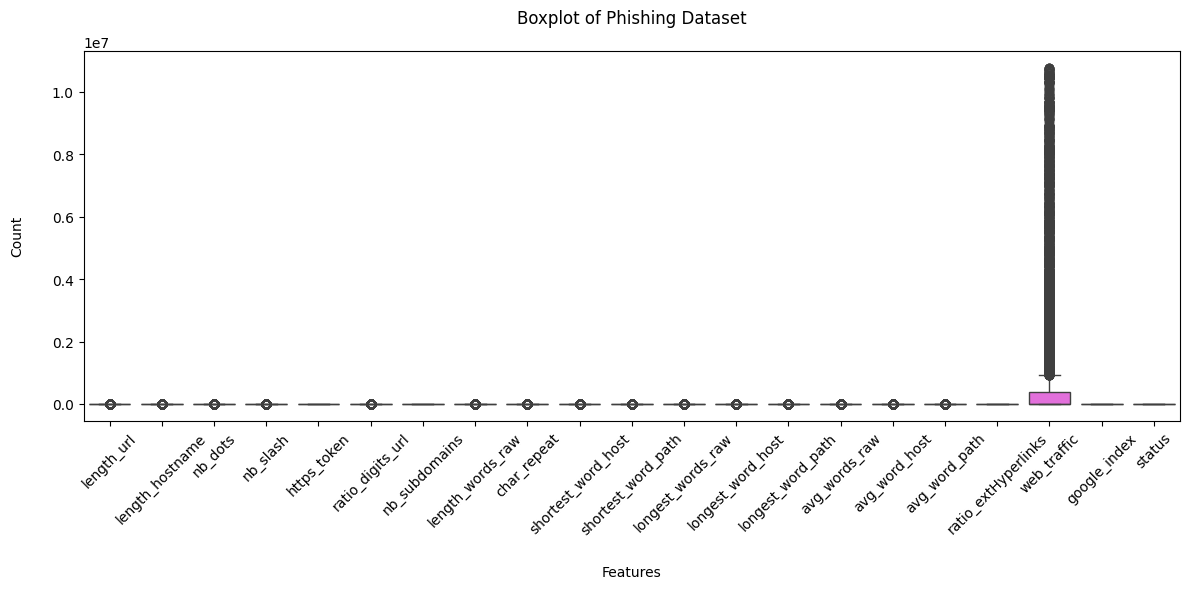

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.title('Boxplot of Phishing Dataset', pad=20)
plt.ylabel('Count', labelpad=20)
plt.xlabel('Features', labelpad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

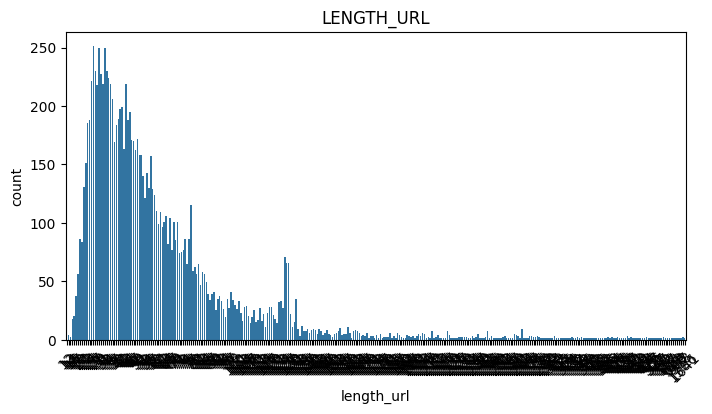

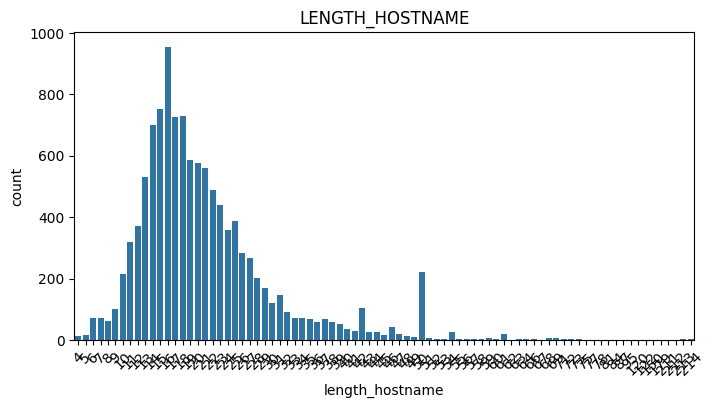

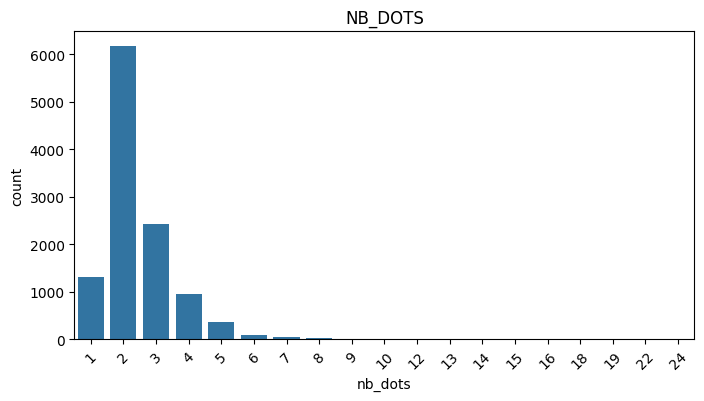

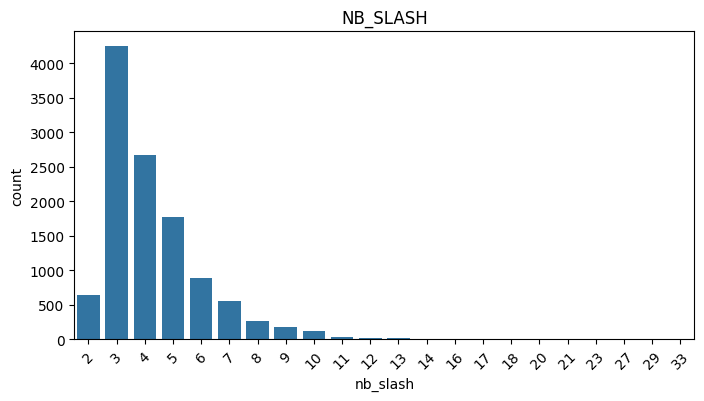

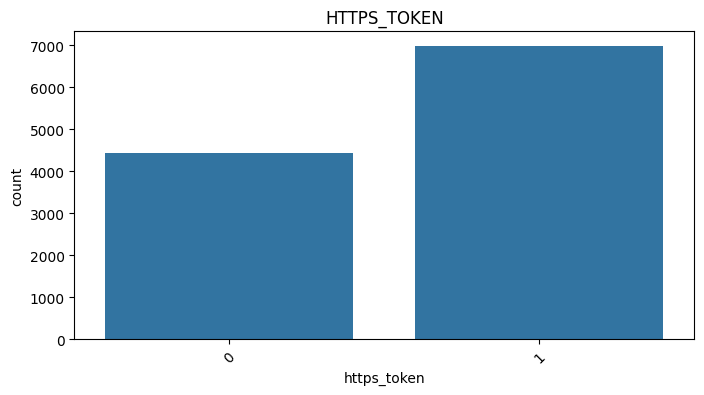

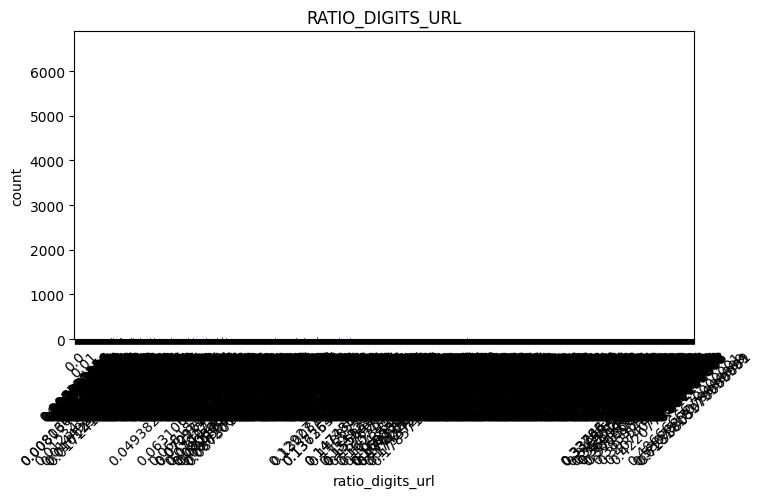

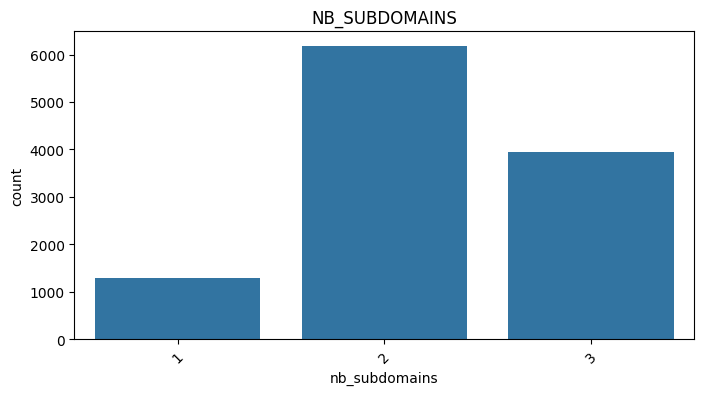

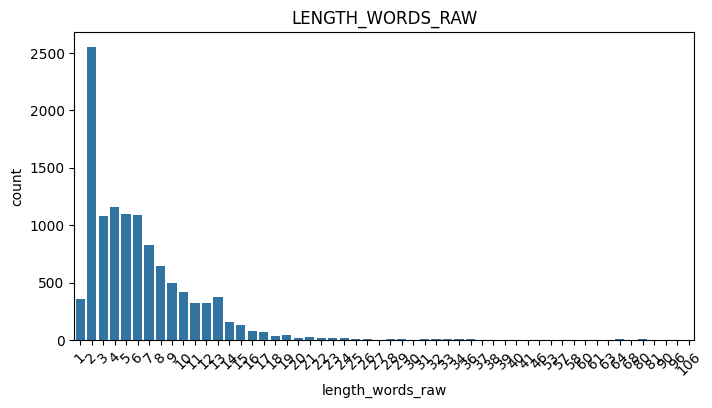

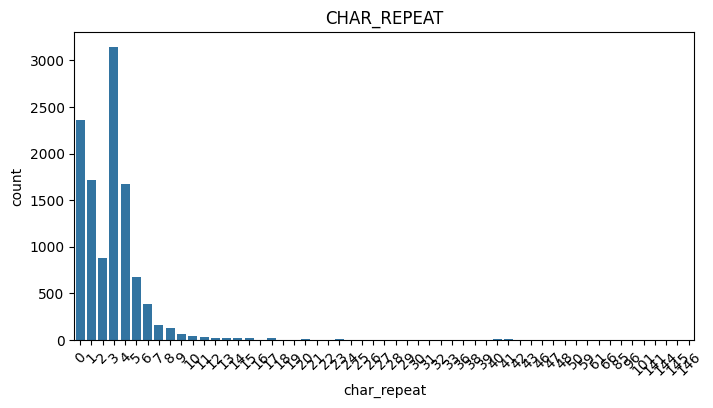

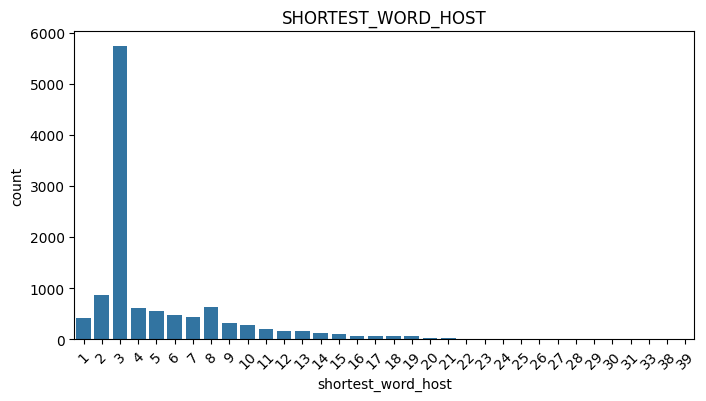

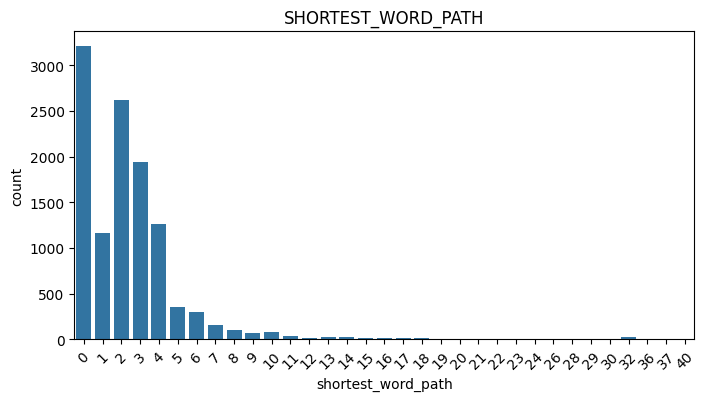

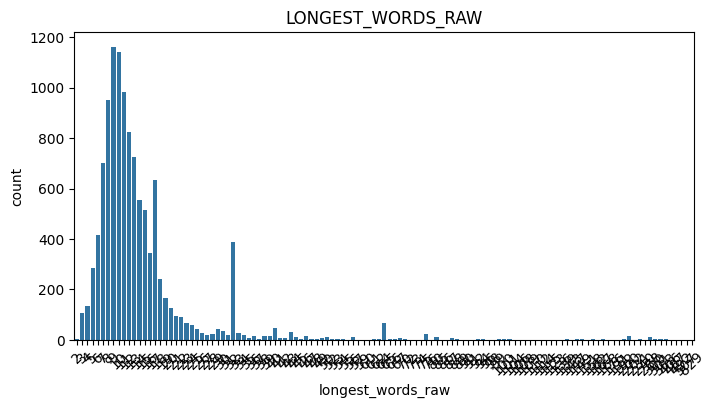

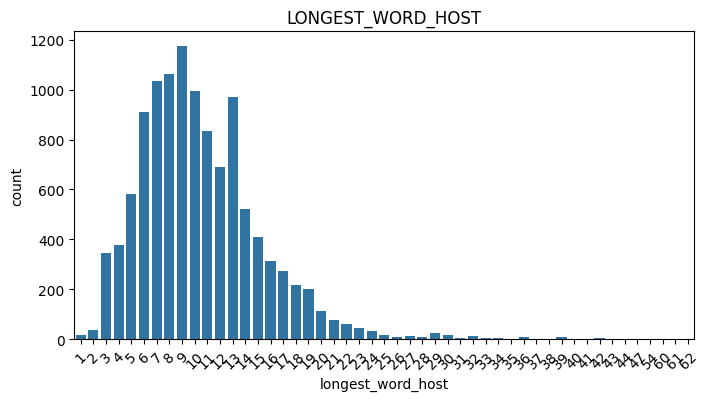

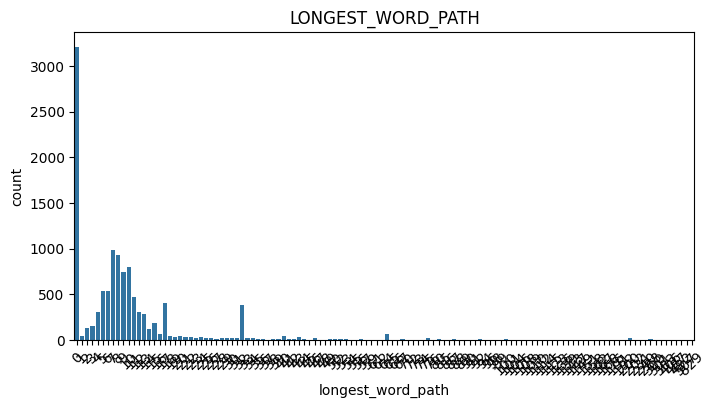

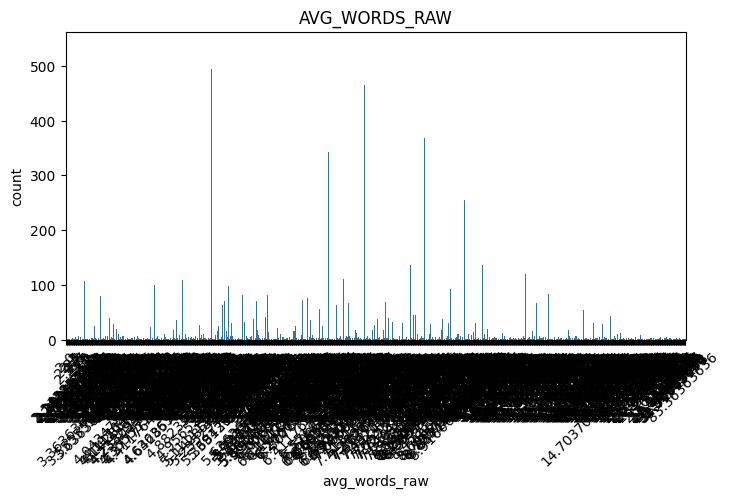

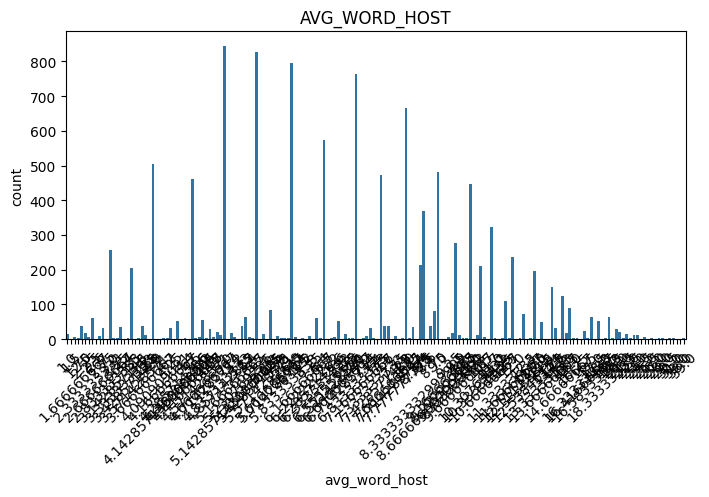

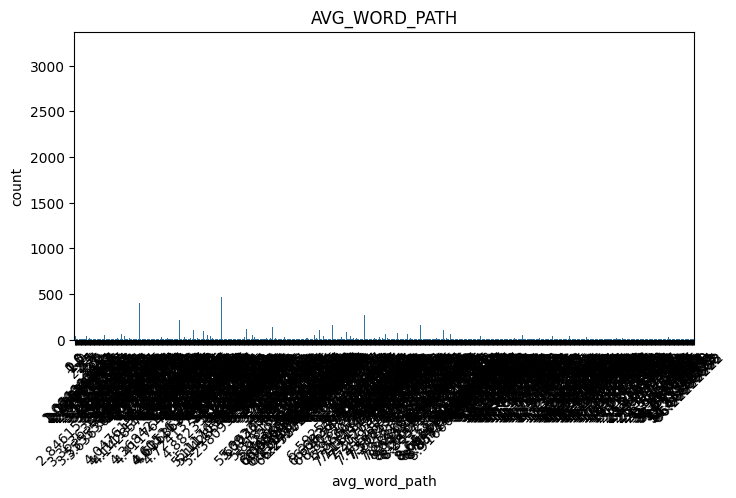

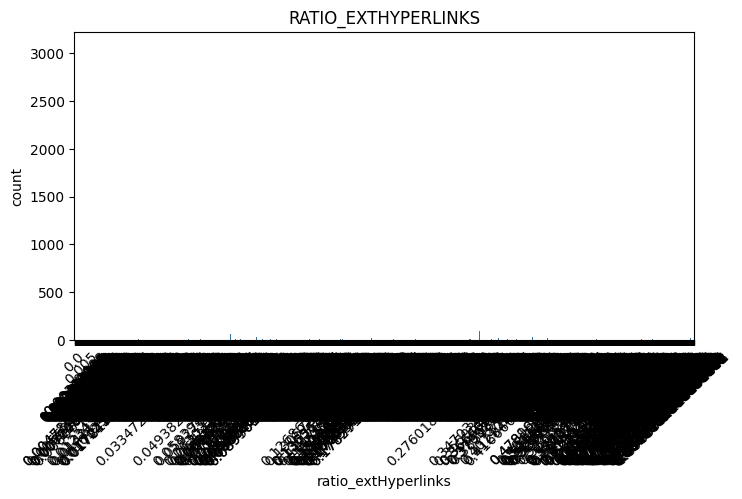

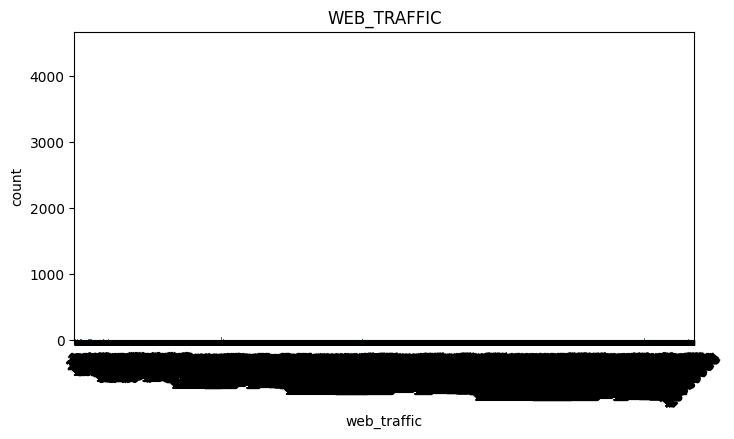

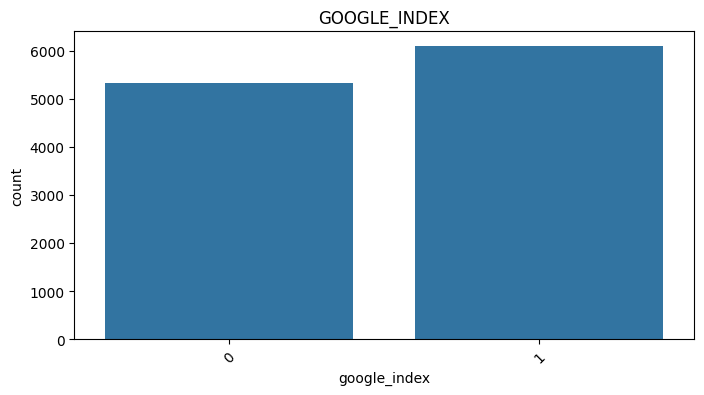

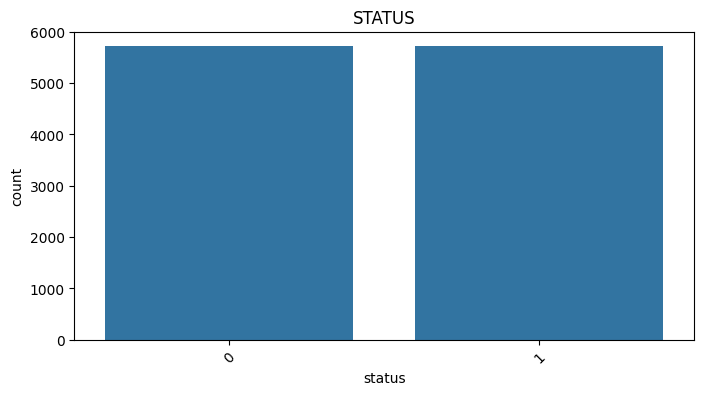

In [38]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=col)
    plt.title(col.upper())
    plt.xticks(rotation=45)
    plt.show()

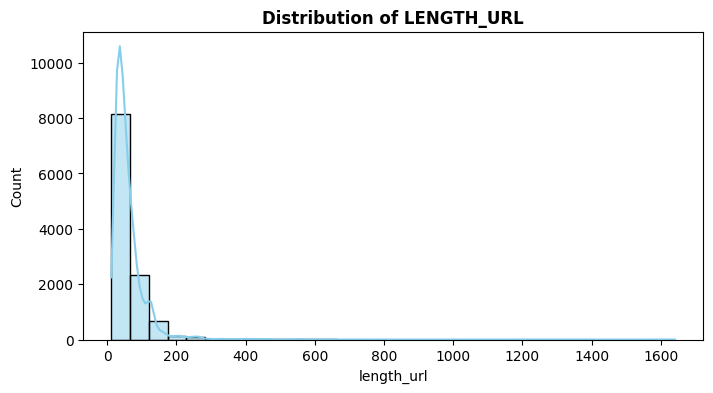

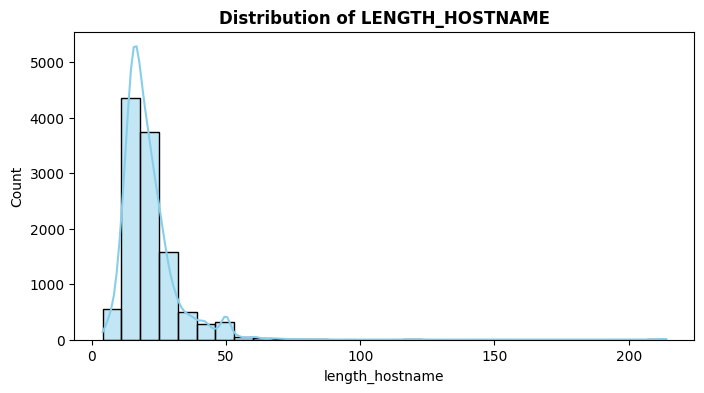

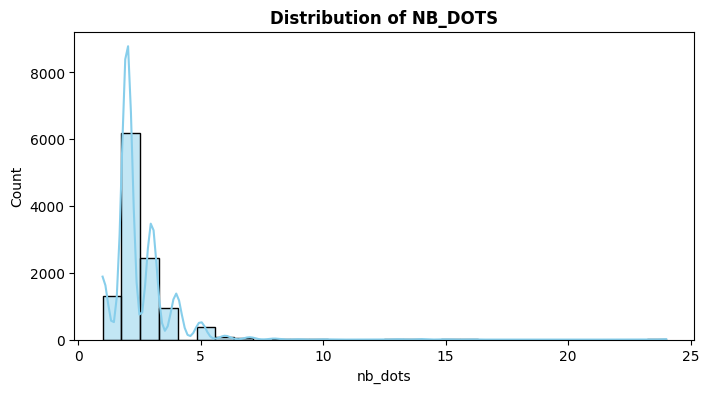

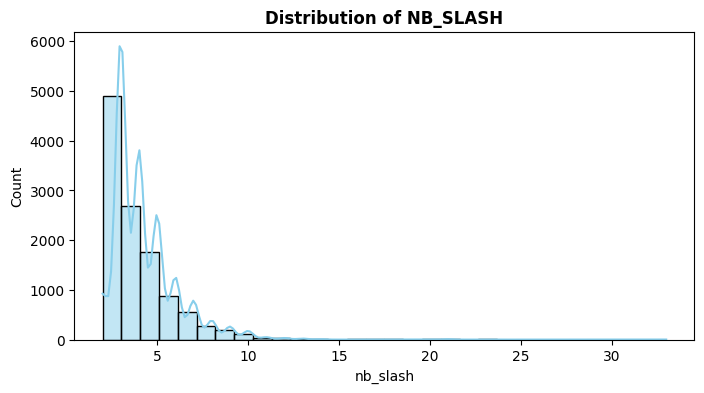

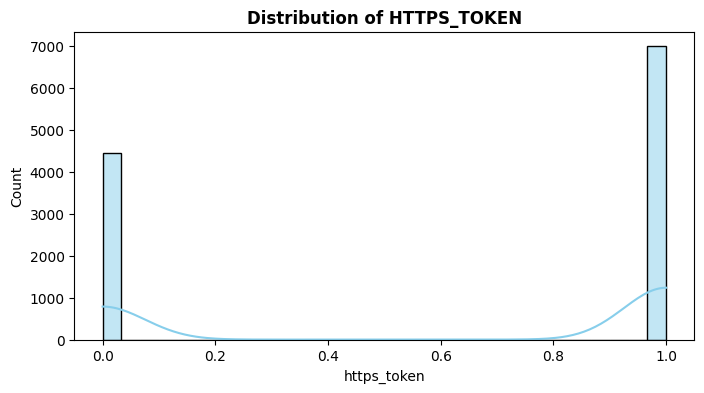

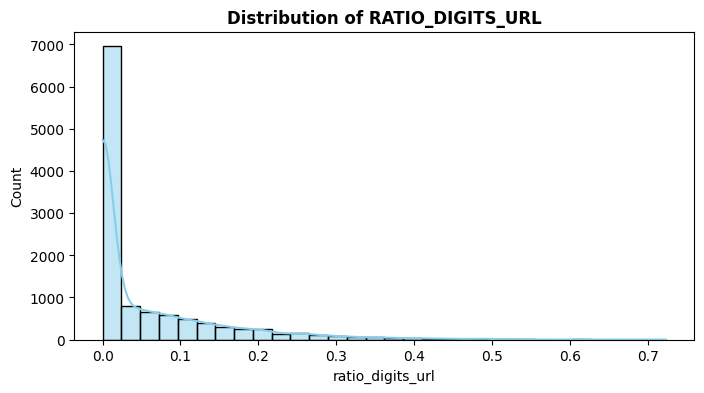

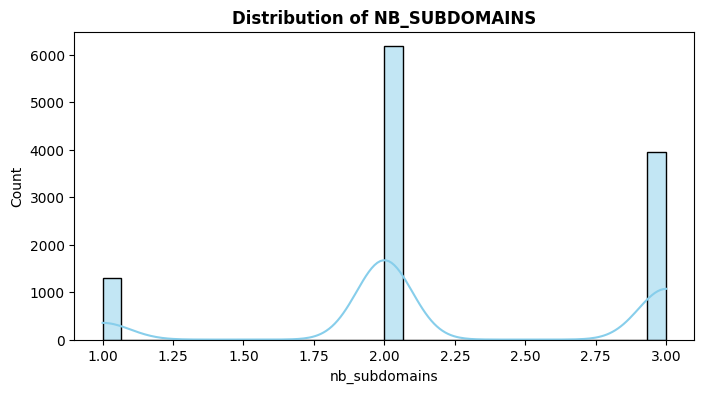

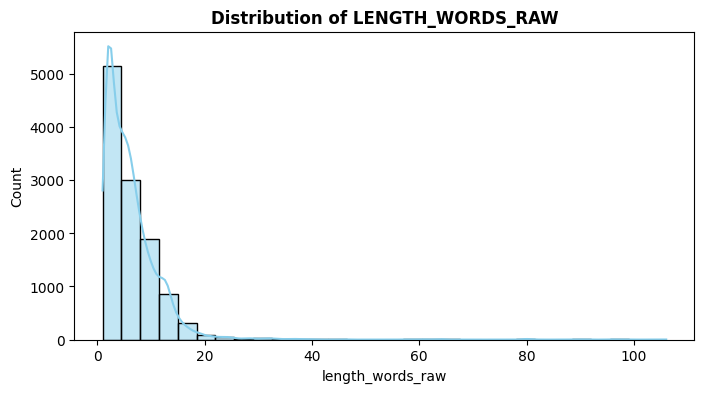

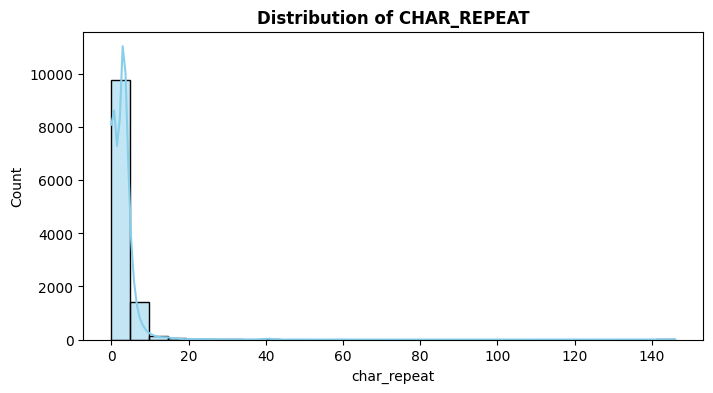

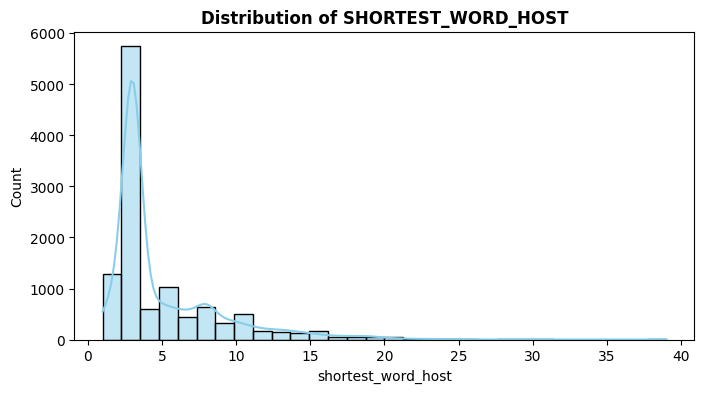

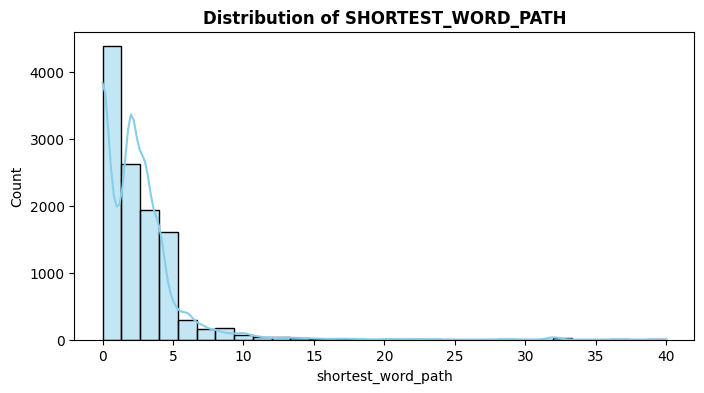

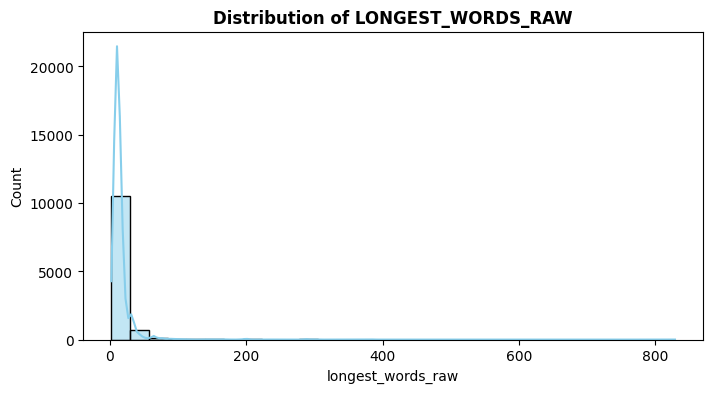

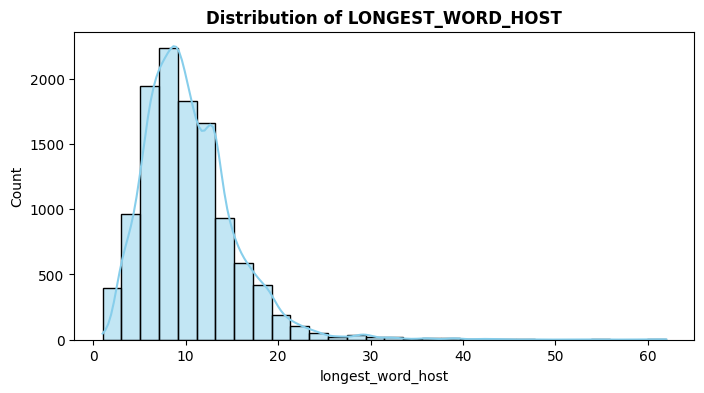

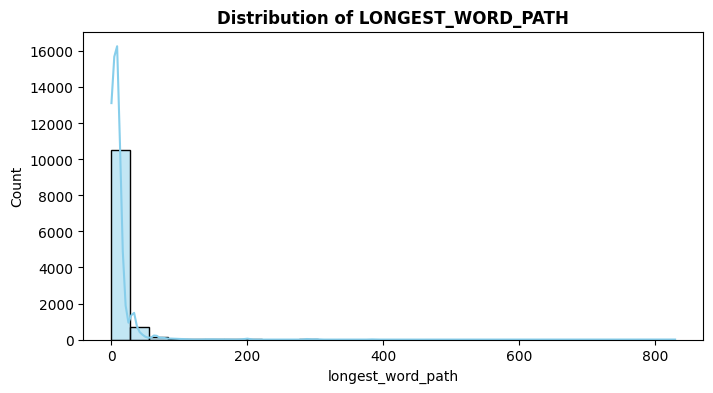

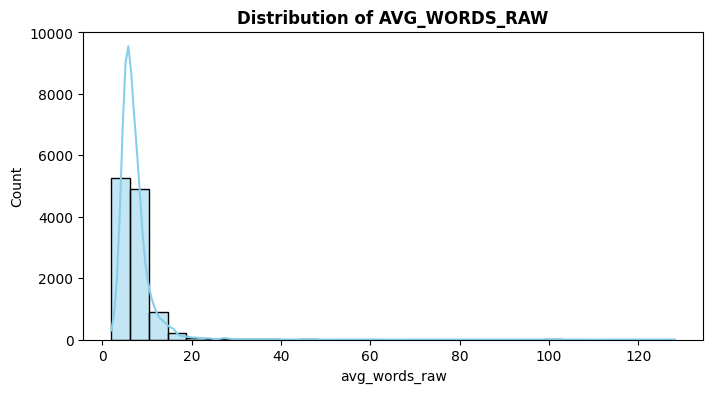

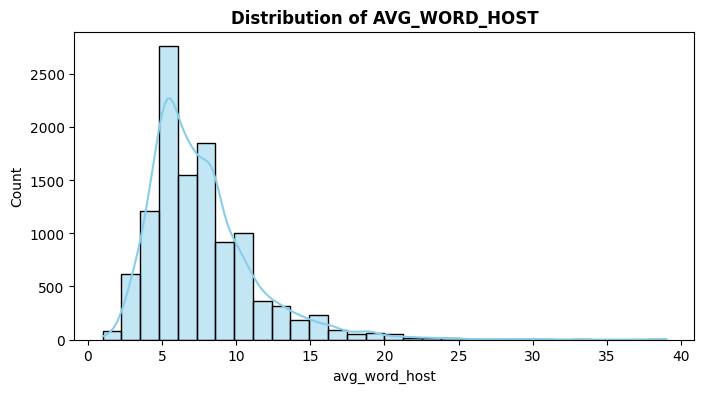

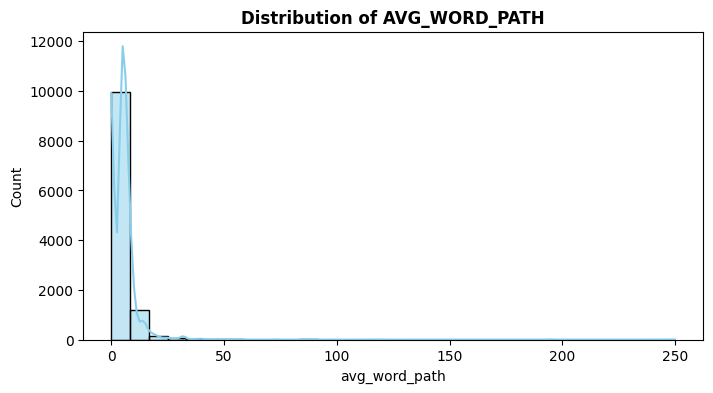

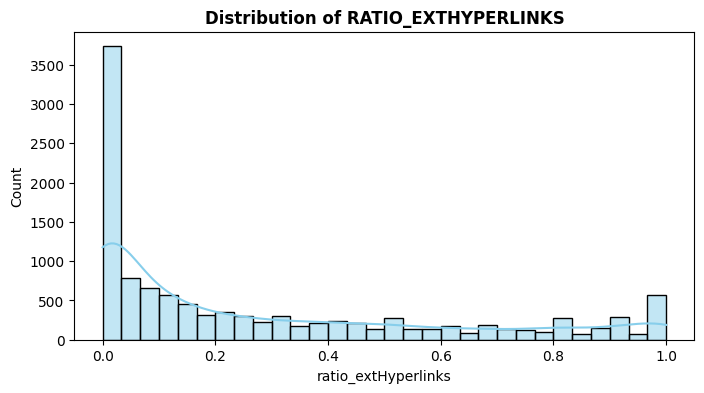

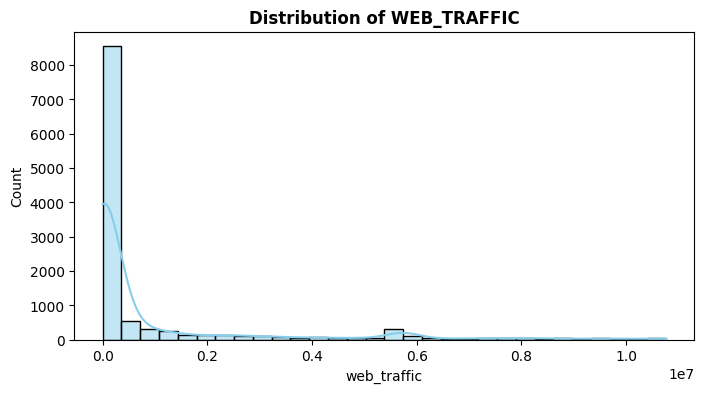

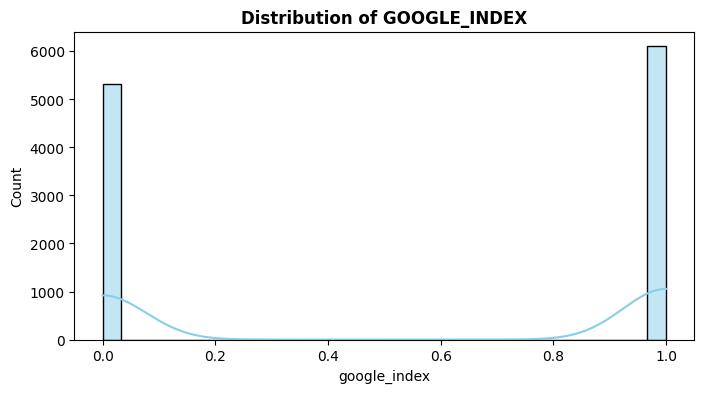

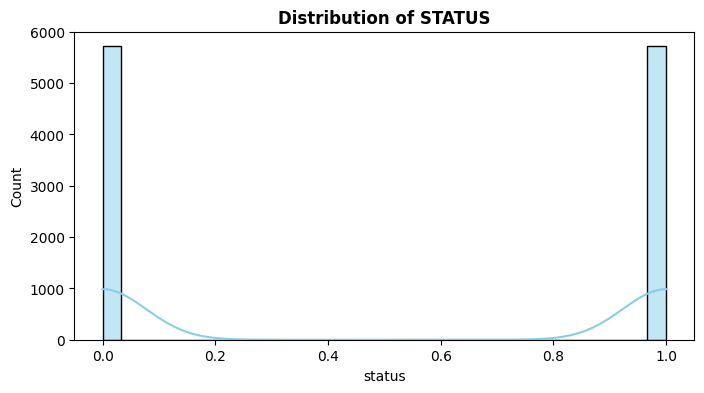

In [ ]:


# Select numerical columns
num_df = df.select_dtypes(include=["int64","float64"])

# Loop through each numerical column
for col in num_df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col.upper()}", fontsize=12, weight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()




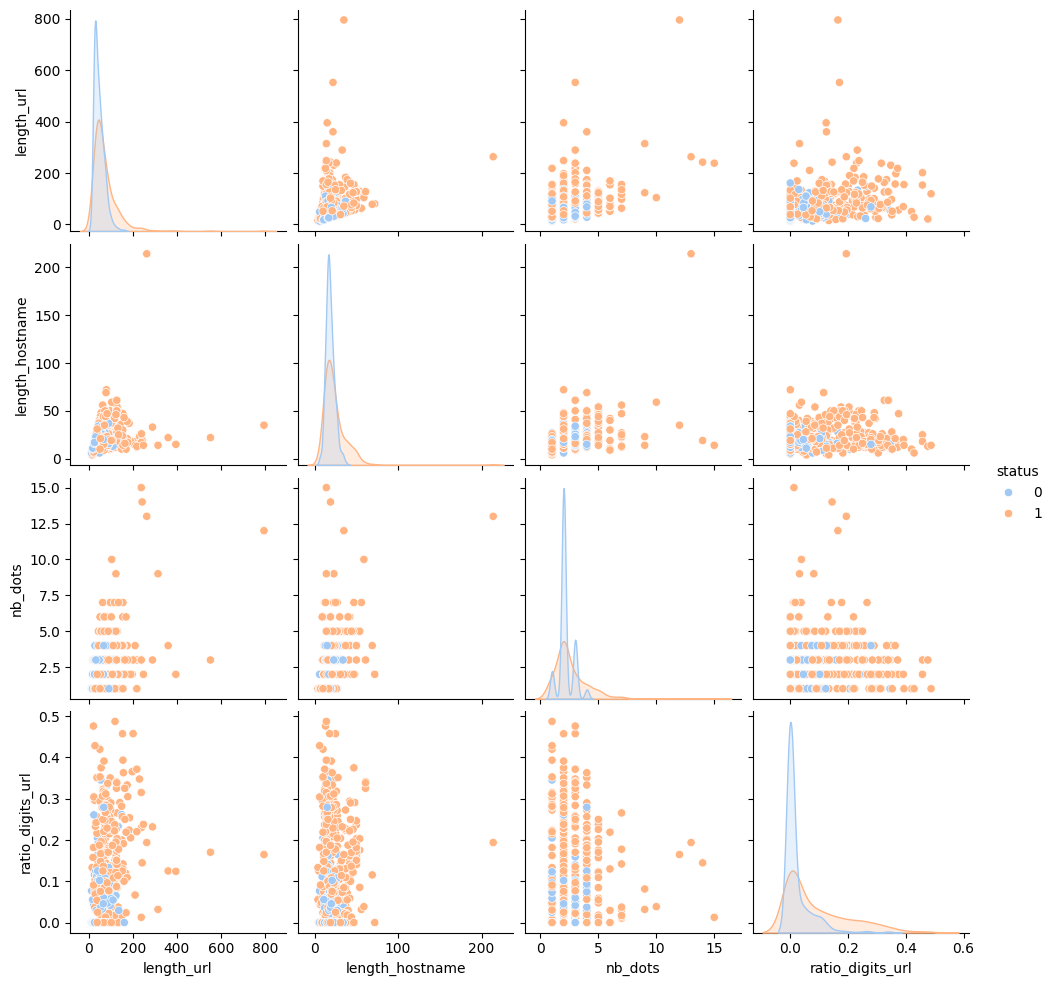

In [44]:

# Select a subset of numeric columns
selected_cols = [
    "length_url",
    "length_hostname",
    "nb_dots",
    "ratio_digits_url",
]

# Pairplot with hue = status
sns.pairplot(df[selected_cols + ["status"]].sample(1000), hue="status", diag_kind="kde", palette="pastel")
plt.show()


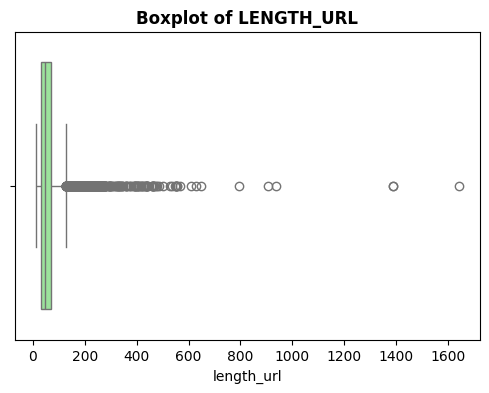

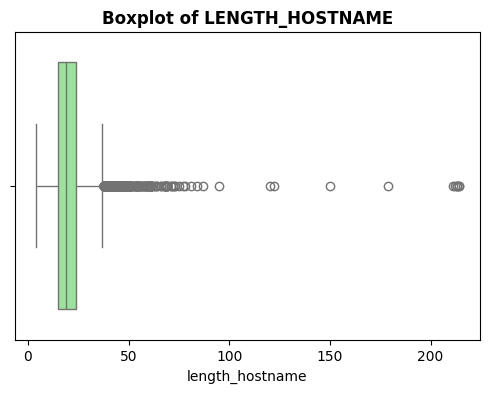

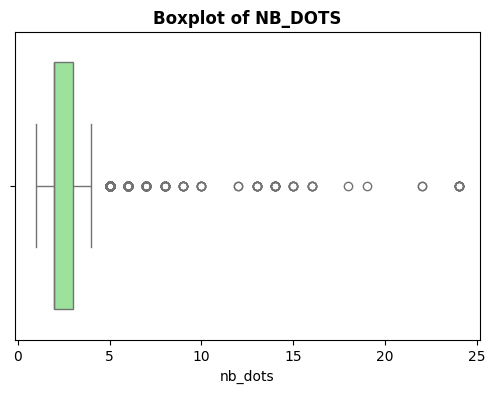

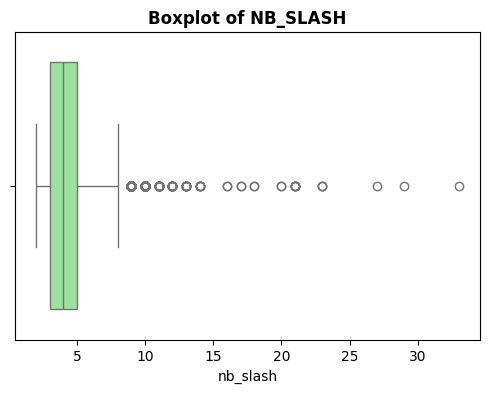

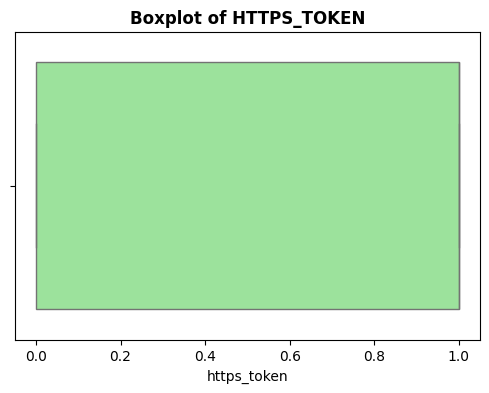

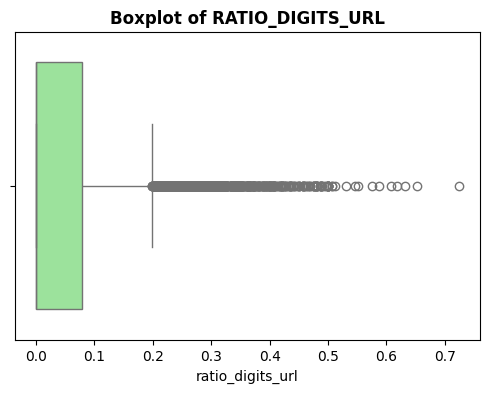

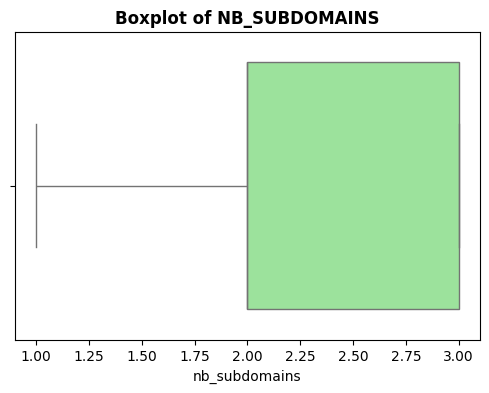

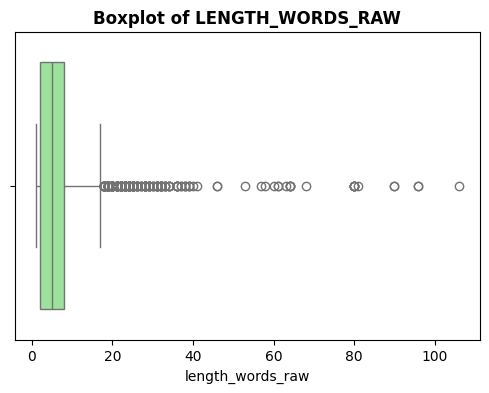

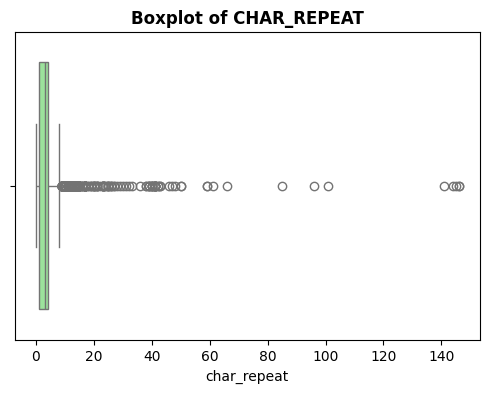

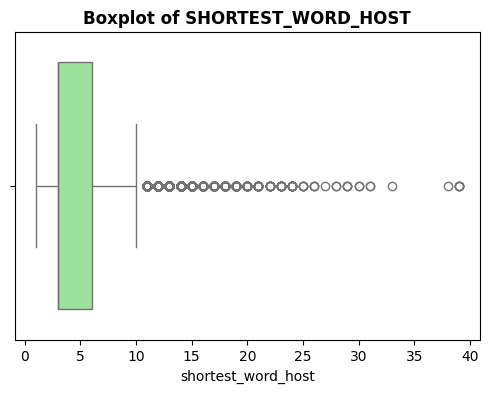

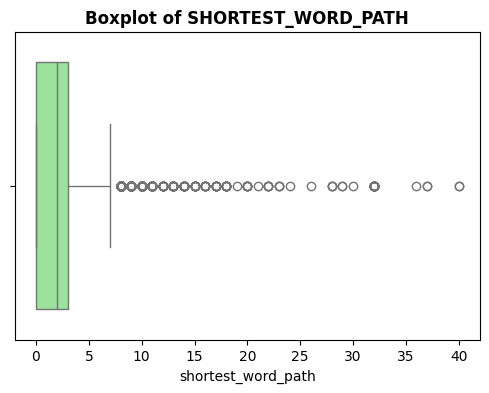

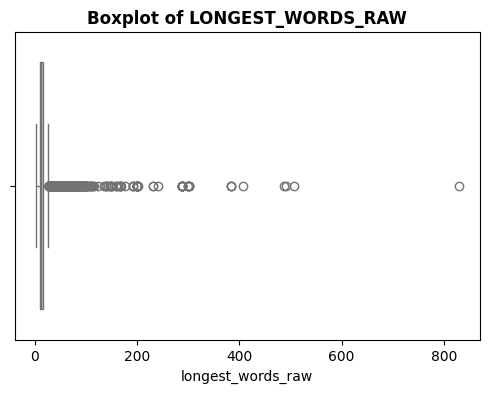

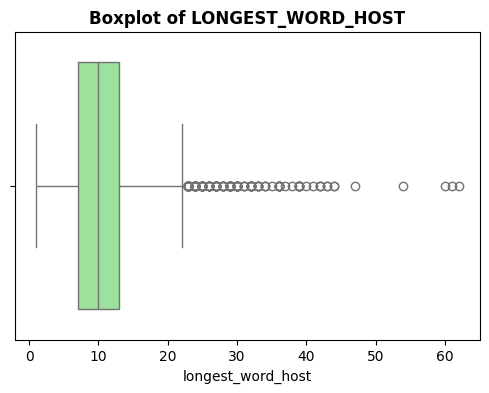

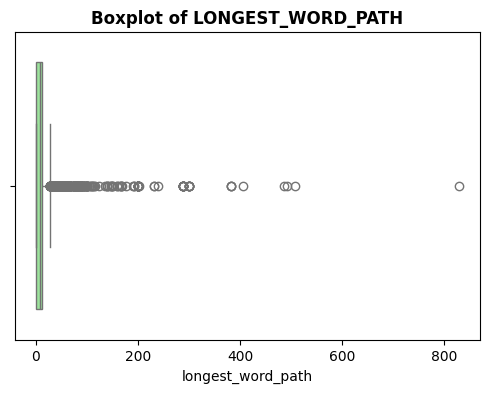

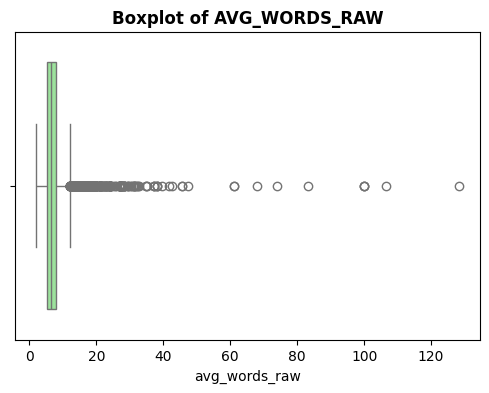

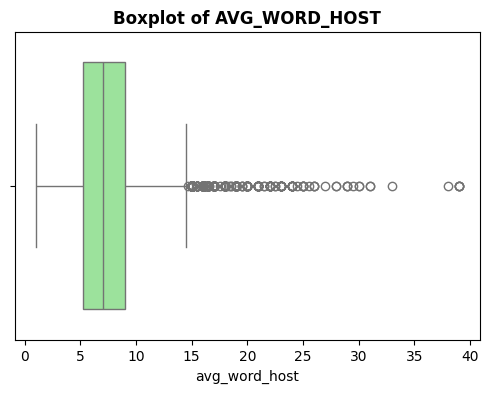

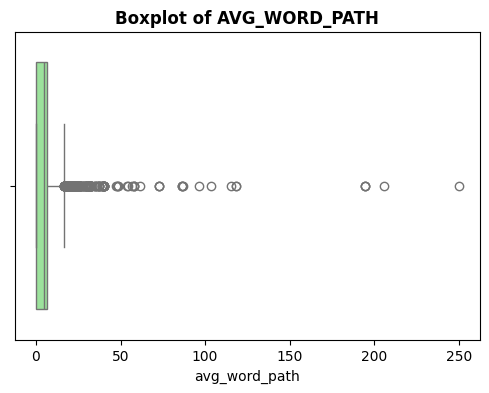

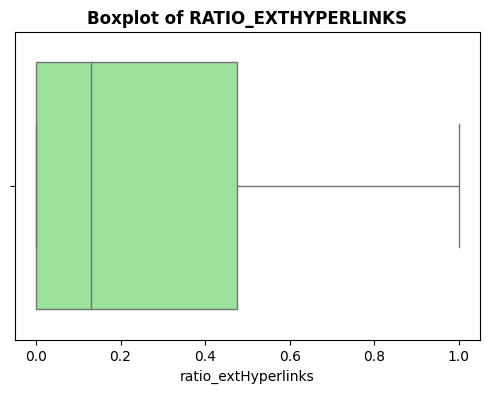

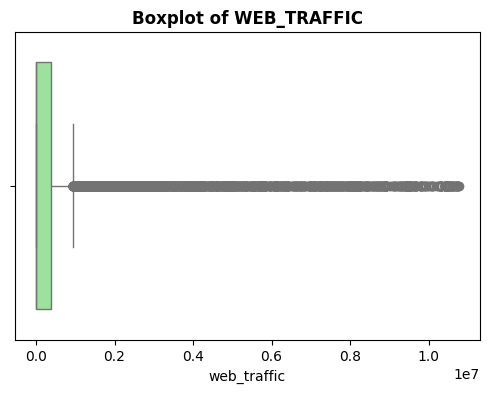

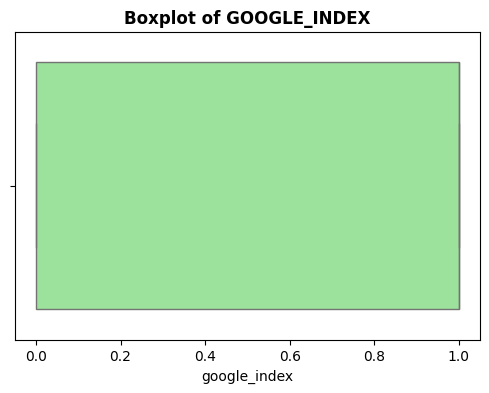

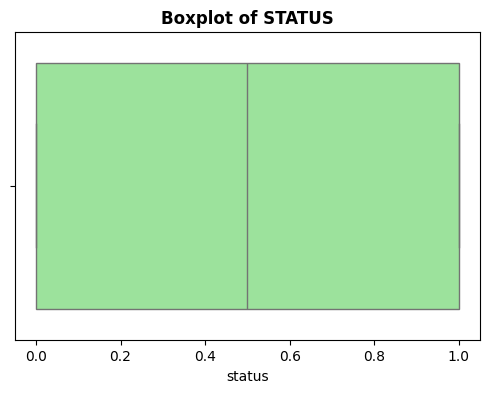

In [48]:
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Boxplot of {col.upper()}", fontsize=12, weight="bold")
    plt.show()


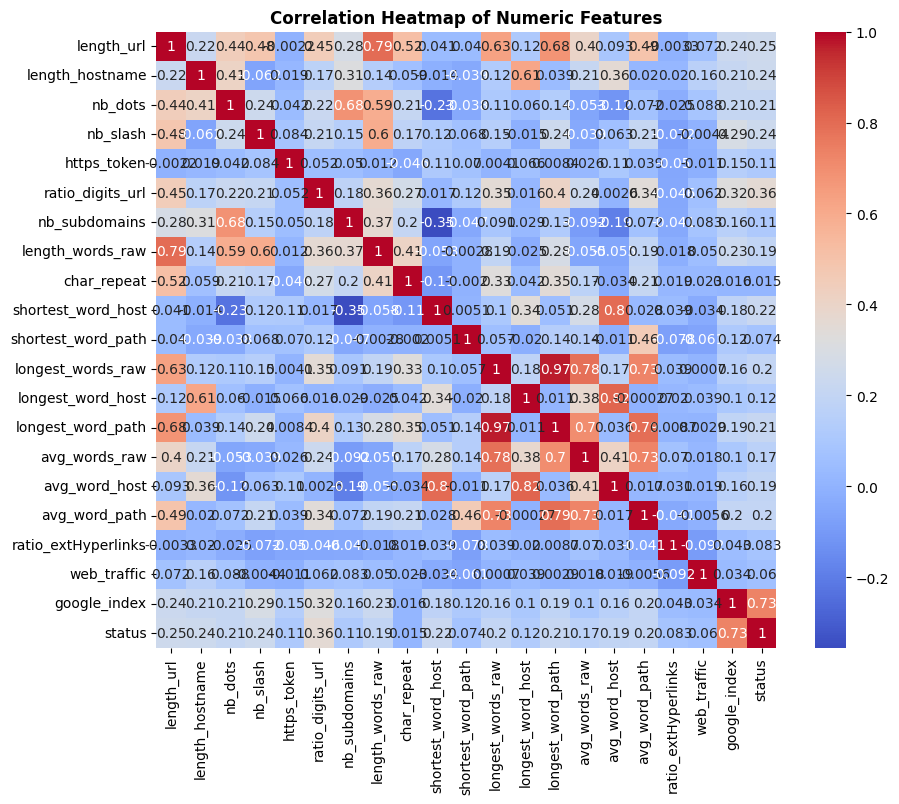

In [49]:
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features", fontsize=12, weight="bold")
plt.show()


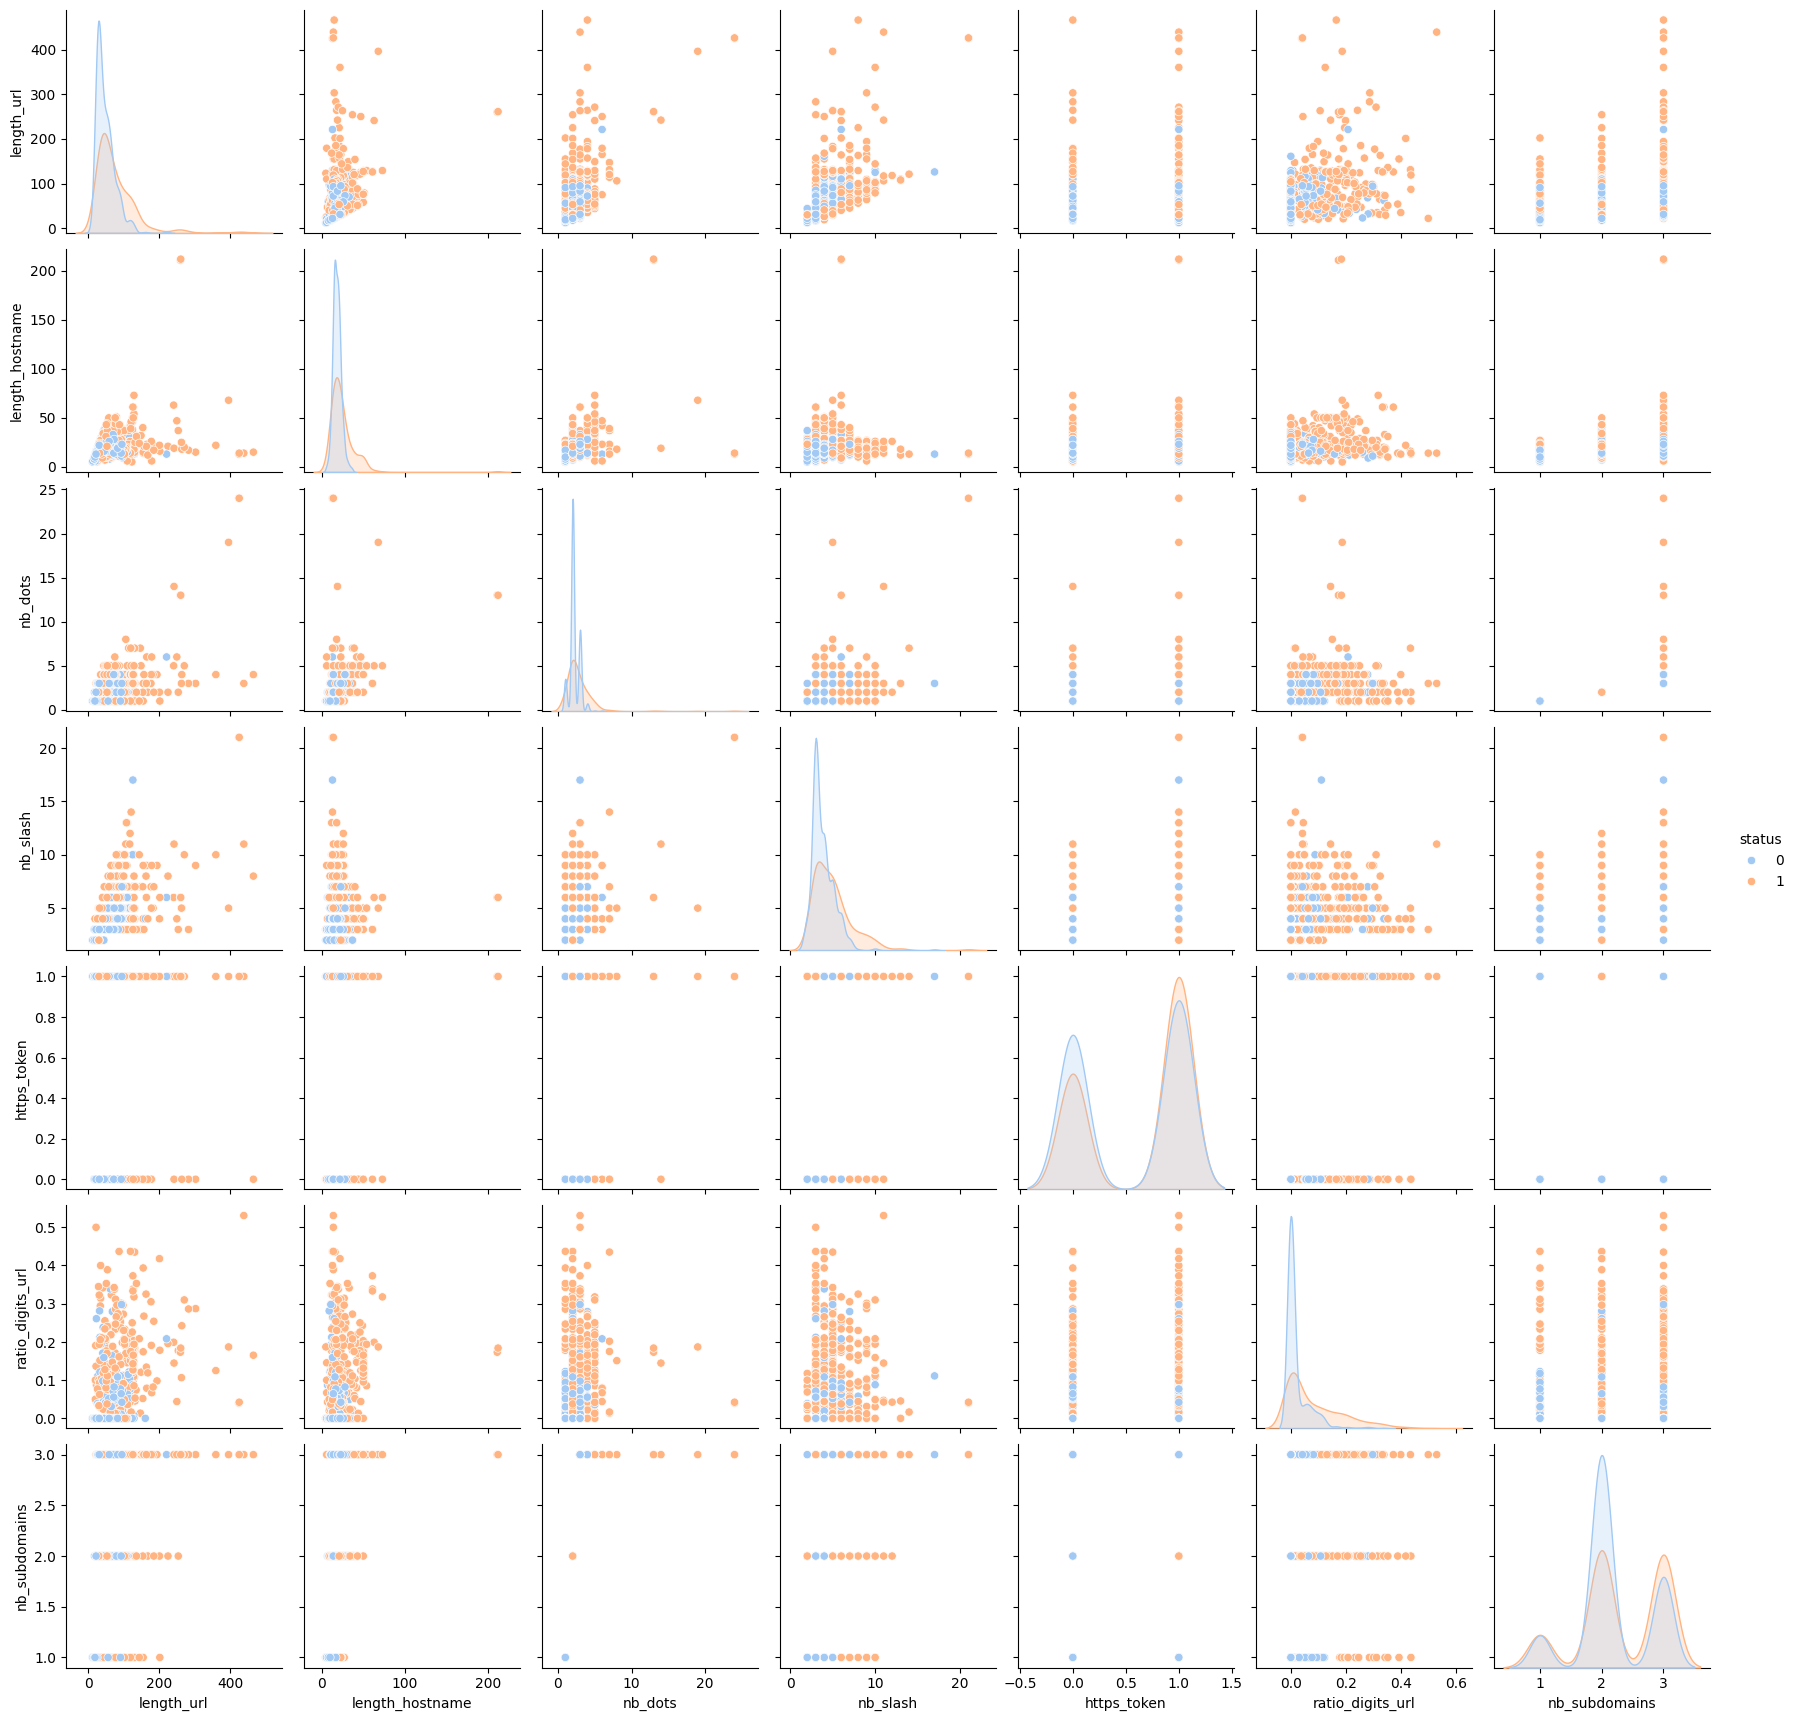

In [53]:

# Choose a subset of numeric columns + target
selected_cols = [
    "length_url",
    "length_hostname",
    "nb_dots",
    "nb_slash",
    "https_token",
    "ratio_digits_url",
    "nb_subdomains"
]  # you can swap in other columns from df.columns

# Pairplot with hue = status
sns.pairplot(
    df[selected_cols + ["status"]].sample(1000),  # include target column
    hue="status",
    diag_kind="kde",
    palette="pastel"
)

plt.show()



In [52]:
print(df.columns.tolist())


['length_url', 'length_hostname', 'nb_dots', 'nb_slash', 'https_token', 'ratio_digits_url', 'nb_subdomains', 'length_words_raw', 'char_repeat', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'ratio_extHyperlinks', 'web_traffic', 'google_index', 'status']


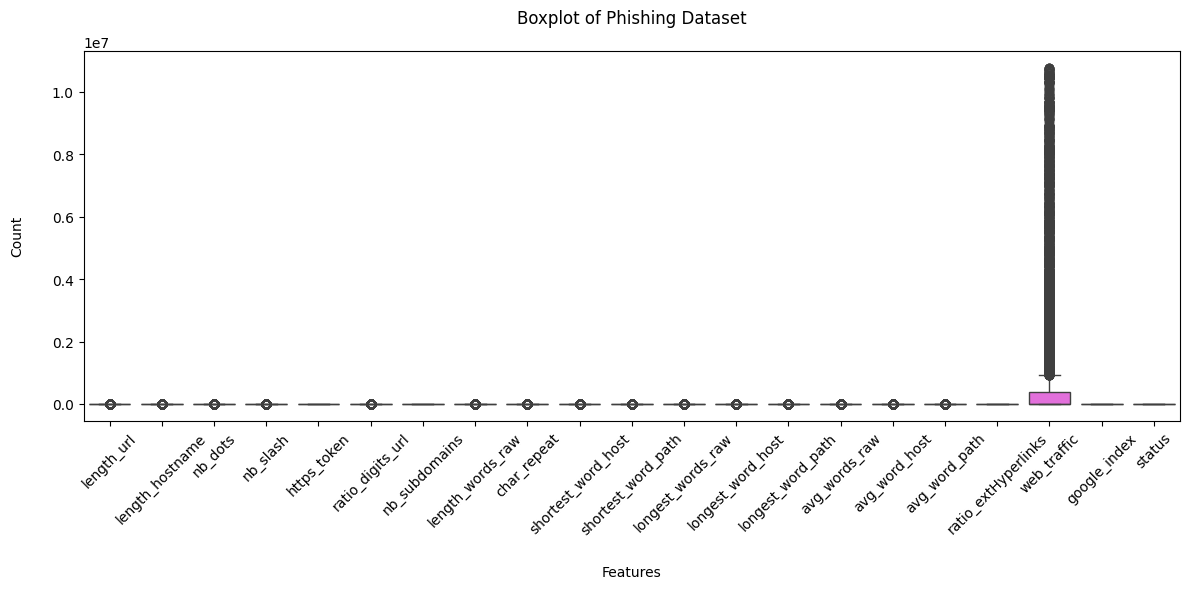

In [31]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.title('Boxplot of Phishing Dataset', pad=20)
plt.ylabel('Count', labelpad=20)
plt.xlabel('Features', labelpad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
from feature_engine.outliers import Winsorizer
winsor=Winsorizer(capping_method='mad',tail='both',fold=1.5)

In [33]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 *IQR
upper_bound = Q3 + 1.5 *IQR

df_capped = df.clip(lower=lower_bound,upper=upper_bound,axis=1)

In [34]:
X=df_capped.drop('status',axis=1)
y=df['status']

In [ ]:
q=MinMaxScaler()
X=q.fit_transform(X)

In [33]:
X

array([[2.15517241e-01, 4.47761194e-01, 5.71428571e-01, ...,
        4.70588235e-01, 0.00000000e+00, 1.00000000e+00],
       [5.60344828e-01, 5.67164179e-01, 0.00000000e+00, ...,
        3.33333330e-02, 0.00000000e+00, 1.00000000e+00],
       [9.82758621e-01, 1.00000000e+00, 8.57142857e-01, ...,
        0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       ...,
       [8.01724138e-01, 3.58208955e-01, 2.85714286e-01, ...,
        5.29411765e-01, 8.55968575e-06, 1.00000000e+00],
       [2.24137931e-01, 7.76119403e-01, 2.85714286e-01, ...,
        6.25000000e-01, 1.00000000e+00, 0.00000000e+00],
       [1.00000000e+00, 2.98507463e-01, 1.00000000e+00, ...,
        5.71428571e-01, 0.00000000e+00, 1.00000000e+00]],
      shape=(11430, 20))

In [34]:
over=SMOTE(random_state=1)
X,y=over.fit_resample(X,y)   #classification

In [18]:
## only categoroical values
# Select categorical columns

cat_df=df.selected_dtypelength_hostname(include="number")
# Loop through each categorical column
for col in cat_df.columns:
    data_counts = df[col].value_counts()
    plt.figure(figsize=(6,6))
    plt.pie(                                                        #only for categorical values
        data_counts,
        labels=data_counts.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette("pastel")
    )
    plt.title(f"Distribution of {col.upper()}", fontsize=12, weight="bold")
    plt.show()


TypeError: 'Series' object is not callable

In [35]:
y

0        0
1        1
2        1
3        0
4        0
        ..
11425    0
11426    1
11427    0
11428    0
11429    1
Name: status, Length: 11430, dtype: int64

In [36]:
y.value_counts() #to check balanced or unbalaced

status
0    5715
1    5715
Name: count, dtype: int64

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [38]:
X_train.shape,X_test.shape

((8001, 20), (3429, 20))

In [39]:
y_train.shape,y_test.shape

((8001,), (3429,))

   KNeighborsClassifier()
********************************************************************************************
accuracy_test 90.60950714494021
accuracy_train 93.26334208223972
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1711
           1       0.92      0.89      0.90      1718

    accuracy                           0.91      3429
   macro avg       0.91      0.91      0.91      3429
weighted avg       0.91      0.91      0.91      3429



   RandomForestClassifier()
********************************************************************************************
accuracy_test 94.19655876348789
accuracy_train 100.0
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1711
           1       0.95      0.94      0.94      1718

    accuracy                           0.94      3429
   macro avg       0.94      0.94      0.94      3429
weighted avg       0.94      0.94      0.

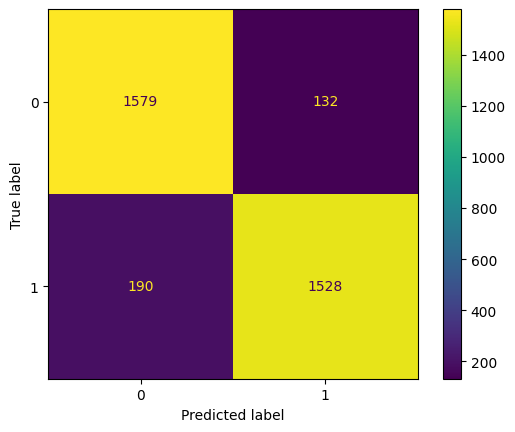

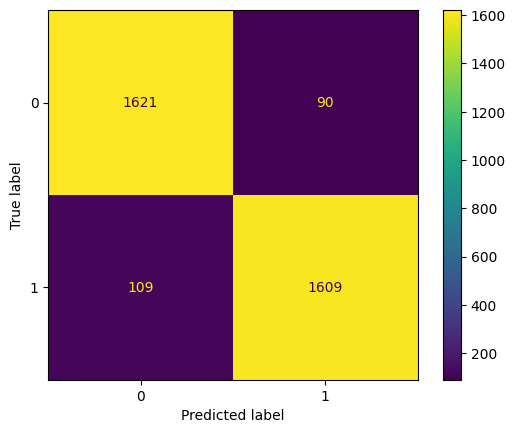

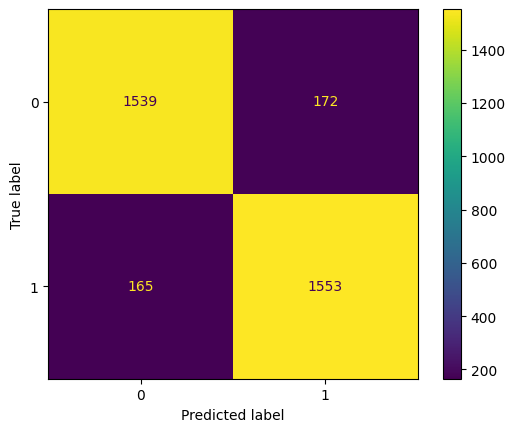

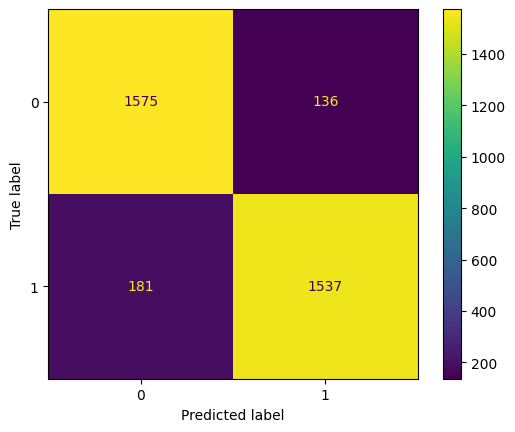

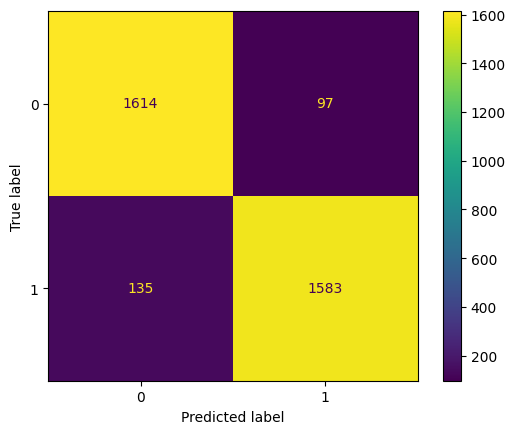

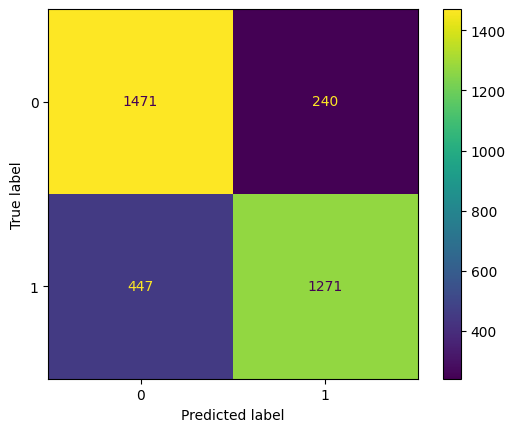

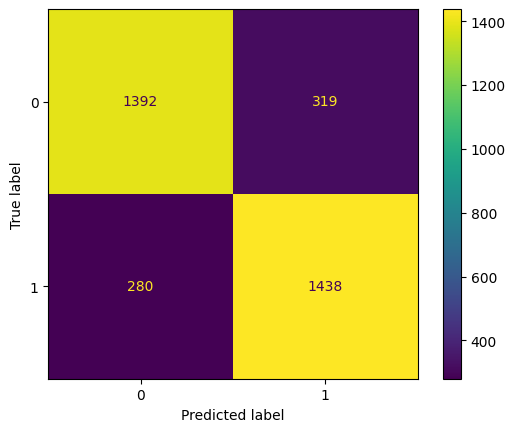

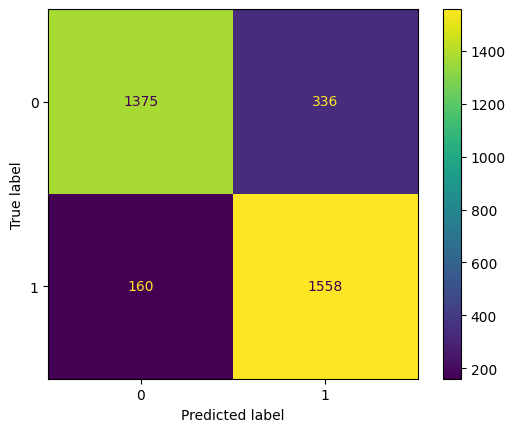

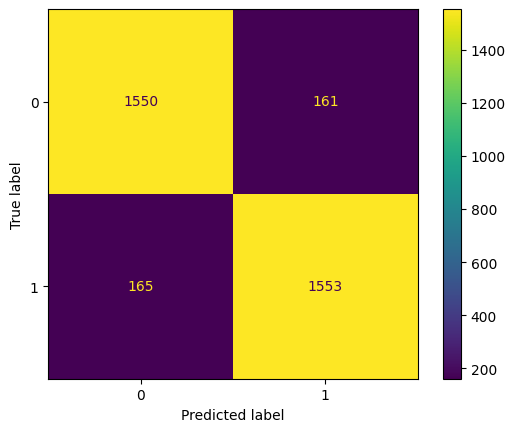

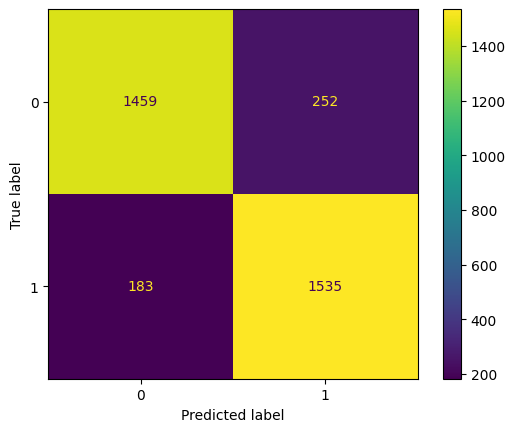

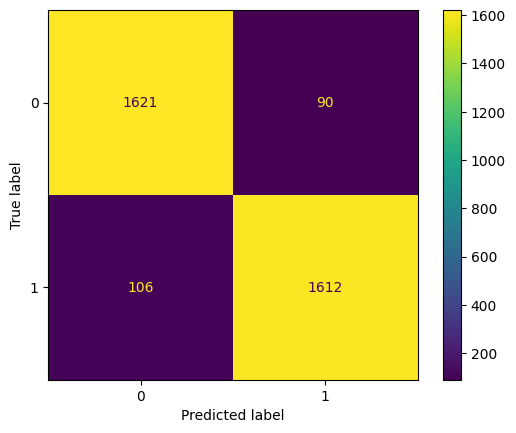

In [40]:
k=KNeighborsClassifier()
r=RandomForestClassifier()
d=DecisionTreeClassifier()
a=AdaBoostClassifier()
h=GradientBoostingClassifier()
g=GaussianNB()
b=BernoulliNB()
m1=MultinomialNB() 
v=SVC()
l=LogisticRegression()
xgb_model = XGBClassifier(
    n_estimators=200,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=6,            # depth of trees
    subsample=0.8,          # fraction of samples per tree
    colsample_bytree=0.8,   # fraction of features per tree
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)



model=[k,r,d,a,h,g,b,m1,v,l,xgb_model]

for i in model:
    print('  ',i)
    print('********************************************************************************************')
    i.fit(X_train,y_train)
    y_pred=i.predict(X_test)
    y_pred_train=i.predict(X_train)
    print('accuracy_test', accuracy_score(y_test,y_pred)*100)
    print('accuracy_train', accuracy_score(y_train,y_pred_train)*100)
    print(classification_report(y_test,y_pred))
    print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
    
    print()
    print()

CROSS VALIDATION 

In [ ]:
from sklearn.model_selection import cross_val_score
print("Cross validation score for all models on training data:")
for i in model:
    print("    ",i.__class__.__name__)
    print("***********************************************************************************")
    score = cross_val_score(i,X,y,cv=5,scoring='accuracy',n_jobs=-1)
    print(f"cv accuracy scores:{score}")
    print(f"Mean Accuracy:{np.mean(score)*100:2f}%/n")
    
                          
                          


Cross validation score for all models on training data:
     KNeighborsClassifier
***********************************************************************************
cv accuracy scores:[0.9208224  0.9160105  0.9063867  0.90201225 0.90507437]
Mean Accuracy:91.006124%/n
     RandomForestClassifier
***********************************************************************************
cv accuracy scores:[0.95231846 0.94488189 0.94356955 0.9391951  0.94706912]
Mean Accuracy:94.540682%/n
     DecisionTreeClassifier
***********************************************************************************
cv accuracy scores:[0.91994751 0.91251094 0.9063867  0.9063867  0.91644794]
Mean Accuracy:91.233596%/n
     AdaBoostClassifier
***********************************************************************************
cv accuracy scores:[0.91382327 0.89895013 0.90988626 0.8967629  0.90769904]
Mean Accuracy:90.542432%/n
     GradientBoostingClassifier
**********************************************************

hypertuning

In [ ]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for RandomForest ... ")
param_grid = {'n_estimators': [50, 100, 200],'max_depth': [None, 10, 20, 30],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

rf = RandomForestClassifier(random_state=1)
# Using n_iter=5 and cv=3 to keep tuning time reasonable. Increase for better results.
grid_search = GridSearchCV(
estimator=rf, param_grid=param_grid,
cv=3, scoring='accuracy', n_jobs =- 1
) 

grid_search.fit(X_train, y_train)

print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_*100:.2f}%")

R=grid_search.best_estimator_
y_pred_r=R.predict(X_test)
y_pred_r

In [ ]:
df.head(10)

In [ ]:
y_new=R.predict(q.transform([[37,19,3,3,1,0.000000,3,4,4,3,3,11,11,6,5.750000,7.0,4.500000,0.470588,0,1]]))
if y_new==0:
    print("Legitimate")
else:
    print("phishing")

In [ ]:
df.corr()['status'].sort_values(ascending=False)    

In [ ]:
df.columns

In [ ]:
df.head(5)


In [ ]:

length_url = float(input("Enter URL length: "))
length_hostname = float(input("Enter hostname length: "))
nb_dots = int(input("Enter number of dots: "))
nb_slash = int(input("Enter number of slashes: "))
https_token = int(input("Contains HTTPS token? (0/1): "))
ratio_digits_url = float(input("Enter ratio of digits in URL: "))
nb_subdomains = int(input("Enter number of subdomains: "))
length_words_raw = float(input("Enter length of words (raw): "))
char_repeat = int(input("Enter character repeat count: "))
shortest_word_host = float(input("Enter shortest word in host: "))
shortest_word_path = float(input("Enter shortest word in path: "))
longest_words_raw = float(input("Enter longest words (raw): "))
longest_word_host = float(input("Enter longest word in host: "))
longest_word_path = float(input("Enter longest word in path: "))
avg_words_raw = float(input("Enter average words (raw): "))
avg_word_host = float(input("Enter average word length in host: "))
avg_word_path = float(input("Enter average word length in path: "))
ratio_extHyperlinks = float(input("Enter ratio of external hyperlinks: "))
web_traffic = int(input("Enter web traffic value: "))
google_index = int(input("Google indexed? : "))



sample = [[length_url, length_hostname, nb_dots, nb_slash, https_token,
           ratio_digits_url, nb_subdomains, length_words_raw, char_repeat,
           shortest_word_host, shortest_word_path, longest_words_raw,
           longest_word_host, longest_word_path, avg_words_raw,
           avg_word_host, avg_word_path, ratio_extHyperlinks,
           web_traffic, google_index]]

# Scale and predict
sample_scaled = q.transform(sample)   # q is your fitted MinMaxScaler
y_new = r.predict(sample_scaled)      # r is your trained model (RandomForest/XGBoost)

# Output result
if y_new[0] == 0:
    print("Legitimate")
else:
    print("Phishing")
3



ValueError: could not convert string to float: ''

In [ ]:
import pickle

In [ ]:
pickle.dump(R,open('URL_phishing.save','wb'))
pickle.dump(q,open('URL_scalar.save','wb'))
pickle.dump(le,open('URL_phishing_encoder.save','wb'))


data visualization
